In [2]:
# Implementing Floyd–Steinberg dithering
from PIL import Image 
import numpy as np
import matplotlib.pyplot as plt
import timeit

(512, 512)
float64


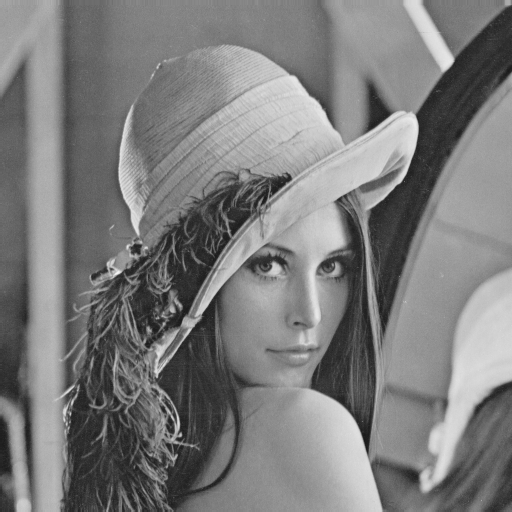

In [3]:
# loading image
image = Image.open("lenna.png").convert("L")
image_np = np.array(image)
image_np = image_np.astype(np.float64)

print(image_np.shape)  # (height, width, channels) for RGB
print(image_np.dtype)  # Usually uint8
image

# Lloyd-Steinberg Dithering

In [4]:
def find_closest_palette_color(pixel: np.float64) -> np.float64:
    if(pixel < 128):
        return 0
    else:
        return 255

def Lloyd_Steinberg_Dithering(src_image: np.array) -> np.array:
    dst_image = np.copy(src_image).astype(np.float64)
    err_image = np.zeros_like(src_image)

    height, width = src_image.shape[:2]

    # linearizing image would be still be optimal to add

    for y in range(height):
        for x in range(width):
            old_pixel = dst_image[y, x]
            new_pixel = find_closest_palette_color(old_pixel)   
            dst_image[y, x] = new_pixel
            quant_error = old_pixel - new_pixel
            # print(f"Error is {quant_error}")
            err_image[y, x] = quant_error

            # error diffusion
            # could also do boundary check per error push value
            if ((x + 1) < width) and ((x - 1) >= 0) and ((y - 1) >= 0) and ((y + 1) < height):
                dst_image[y, x + 1] = dst_image[y, x + 1] + quant_error * 7/16
                dst_image[y + 1, x - 1] = dst_image[y + 1, x - 1] + quant_error * 3/16
                dst_image[y + 1, x] = dst_image[y + 1, x] + quant_error * 5/16
                dst_image[y + 1, x + 1] = dst_image[y + 1, x + 1] + quant_error * 1/16

    # replacing 1's with 255 for displaying
    # dst_image[dst_image == 1] = 255

    return dst_image, err_image

In [5]:
dithered_img_ls, err_img_ls = Lloyd_Steinberg_Dithering(image_np)

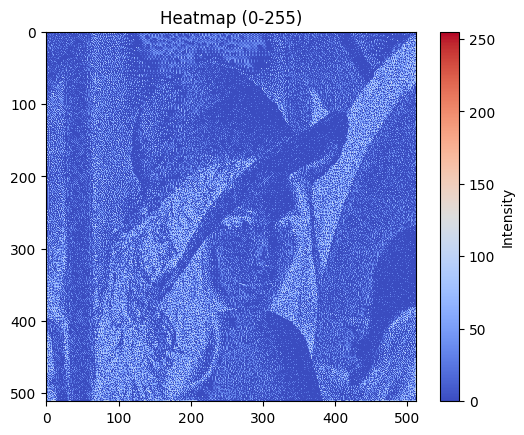

In [6]:
dst_img = Image.fromarray(dithered_img_ls)
plt.imshow(err_img_ls, cmap='coolwarm', vmin=0, vmax=255)
plt.colorbar(label='Intensity')
plt.title('Heatmap (0-255)')
plt.show()
dst_img.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


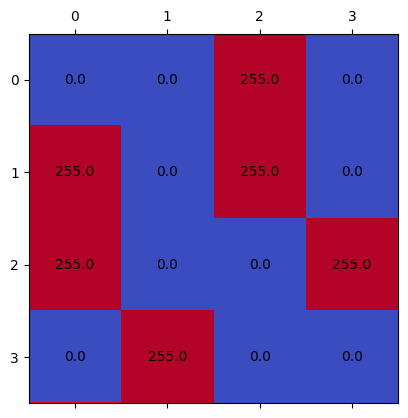

In [7]:
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches

# Animation of it happening
dst_image = np.copy(image_np).astype(np.float64)
err_image = np.zeros_like(image_np)
frames = []

height, width = image_np.shape[:2]

# Animation first frame
frame_4x4 = dst_image[100:104, 100:104]
frames.append(frame_4x4)

# linearizing image would be still be optimal to add

for y in range(height):
    for x in range(width):
        old_pixel = dst_image[y, x]
        new_pixel = find_closest_palette_color(old_pixel)   
        dst_image[y, x] = new_pixel
        quant_error = old_pixel - new_pixel
        # print(f"Error is {quant_error}")
        err_image[y, x] = quant_error

        # error diffusion
        # could also do boundary check per error push value
        if ((x + 1) < width) and ((x - 1) >= 0) and ((y - 1) >= 0) and ((y + 1) < height):
            dst_image[y, x + 1] = dst_image[y, x + 1] + quant_error * 7/16
            dst_image[y + 1, x - 1] = dst_image[y + 1, x - 1] + quant_error * 3/16
            dst_image[y + 1, x] = dst_image[y + 1, x] + quant_error * 5/16
            dst_image[y + 1, x + 1] = dst_image[y + 1, x + 1] + quant_error * 1/16
        
        # if within range of frame
        if(100 <= x < 104) and (100 <= y < 104):
                frames.append(dst_image[100:104, 100:104].copy())          
  
fig, ax = plt.subplots()
cax = ax.matshow(frames[0], cmap='coolwarm', animated = True)  # Display as a colored grid

frame_to_show = frames[0]

for i in range(frame_to_show.shape[0]):
    for j in range(frame_to_show.shape[1]):
        ax.text(j, i, f"{frame_to_show[i, j]}", ha='center', va='center', color='black')

def update(frame):
    # clearing last frame manually to redraw 
    ax.clear()
    frame_to_show = frames[frame]
    
    # adding current frame
    cax = ax.matshow(frame_to_show, cmap='coolwarm', animated = True)  # Display as a colored grid

    # adding text
    for i in range(frame_to_show.shape[0]):
        for j in range(frame_to_show.shape[1]):
            val = np.round(frame_to_show[i, j])
            ax.text(j, i, val, ha='center', va='center', color='black')
            
    # adding current location rectangle
    start_x = -0.5 + (frame % 4)
    start_y = -0.5 + (frame // 4)
    
    rect = patches.Rectangle((start_x, start_y), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    
    return [cax]

ani = FuncAnimation(fig, update, frames=len(frames), interval=1000, blit=True)
ani.save("test.gif")
# plt.show()

# Integer-Based LS dithering

(512, 512)
uint8


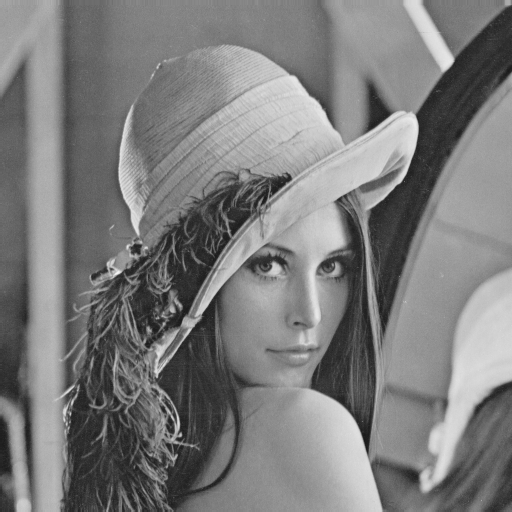

In [11]:
# loading image
image = Image.open("lenna.png").convert("L")
image_np = np.array(image)
image_np = image_np.astype(np.uint8)

print(image_np.shape)  # (height, width, channels) for RGB
print(image_np.dtype)  # Usually uint8
image

In [22]:
# def find_closest_palette_color(pixel: np.float64) -> np.float64:
#     return np.round(pixel / 255)

def find_closest_palette_color(pixel: np.uint8) -> np.uint8:
    if(pixel < 128):
        return 0
    else:
        return 255

def Lloyd_Steinberg_Dithering_int(src_image: np.array) -> np.array:
    dst_image = np.copy(src_image).astype(np.uint8)
    err_image = np.zeros_like(src_image)

    height, width = src_image.shape[:2]

    for y in range(height):
        for x in range(width):
            old_pixel = dst_image[y, x]
            new_pixel = find_closest_palette_color(old_pixel)   
            dst_image[y, x] = new_pixel
            quant_error = old_pixel - new_pixel
            err_image[y, x] = quant_error
            # error diffusion
            # could also do boundary check per error push value
            if ((x + 1) < width) and ((x - 1) >= 0) and ((y - 1) >= 0) and ((y + 1) < height):
                dst_image[y, x + 1] = dst_image[y, x + 1] + ((quant_error * 7) >> 4)
                dst_image[y + 1, x - 1] = dst_image[y + 1, x - 1] + ((quant_error * 3) >> 4)
                dst_image[y + 1, x] = dst_image[y + 1, x] + ((quant_error * 5) >> 4)
                dst_image[y + 1, x + 1] = dst_image[y + 1, x + 1] + ((quant_error * 1) >> 4)

    return dst_image, err_image

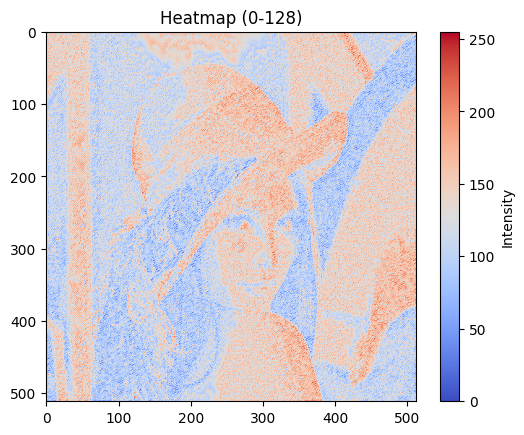

In [ ]:
dithered_img, err_img = Lloyd_Steinberg_Dithering_int(image_np)
dst_img = Image.fromarray(dithered_img)
plt.imshow(err_img, cmap='coolwarm', vmin=0, vmax=255)
plt.colorbar(label='Intensity')
plt.title('Heatmap (0-255)')
plt.show()
dst_img.show()

In [24]:
execution_time = timeit.timeit(lambda: Lloyd_Steinberg_Dithering(image_np), number=3)
print("Average execution time:", execution_time / 10, "seconds")
execution_time = timeit.timeit(lambda: Lloyd_Steinberg_Dithering_int(image_np), number=3)
print("Average execution time:", execution_time / 10, "seconds")

Average execution time: 0.237186994899821 seconds
Average execution time: 0.5461092308003572 seconds


# Atkinson Dithering

In [28]:
def find_closest_palette_color(pixel: np.float64) -> np.uint8:
    # return np.round(pixel / 255)
    if(pixel < 128):
        return 0
    else:
        return 255

def Atkinson_Dithering(src_image: np.array) -> np.array:
    dst_image = np.copy(src_image).astype(np.float64)
    err_image = np.zeros_like(src_image)

    height, width = src_image.shape[:2]

    # linearizing image would be still be optimal to add

    for y in range(height):
        for x in range(width):
            old_pixel = dst_image[y, x]
            # print(f"old_pixel is {old_pixel}")
            new_pixel = find_closest_palette_color(old_pixel)   
            # print(f"new_pixel is {new_pixel}")
            dst_image[y, x] = new_pixel
            quant_error = old_pixel - new_pixel
            # print(f"quant_error is {quant_error}")
            err_image[y,x] = quant_error

            # Error diffusion
            if ((x + 2) < width) and ((y + 2) < height):
                dst_image[y, x + 1] = dst_image[y, x + 1] + quant_error * 1/8
                dst_image[y, x + 2] = dst_image[y, x + 2] + quant_error * 1/8
                dst_image[y + 1, x - 1] = dst_image[y+ 1, x - 1] + quant_error * 1/8
                dst_image[y+ 1, x] = dst_image[y+ 1, x] + quant_error * 1/8
                dst_image[y+1, x + 1] = dst_image[y+1, x + 1] + quant_error * 1/8
                dst_image[y+2, x] = dst_image[y+2, x] + quant_error * 1/8

    # replacing 1's with 255 for displaying
    # dst_image[dst_image == 1] = 255

    return dst_image, err_image

In [29]:
dithered_img_a, err_img_a = Atkinson_Dithering(image_np)

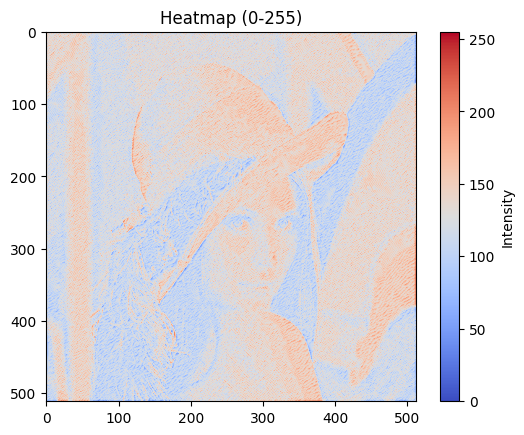

In [31]:
dst_img = Image.fromarray(dithered_img_a)
plt.imshow(err_img_a, cmap='coolwarm', vmin=0, vmax=255)
plt.colorbar(label='Intensity')
plt.title('Heatmap (0-255)')
plt.show()
dst_img.show()

# Jarvis, Judice, and Ninke Dithering

In [145]:
def find_closest_palette_color(pixel: np.float64) -> np.float64:
    # return np.round(pixel / 255)
    if(pixel < 128):
        return 0
    else:
        return 255

def JJN_Dithering(src_image: np.array) -> np.array:
    dst_image = np.copy(src_image)
    err_image = np.zeros_like(src_image)

    height, width = src_image.shape[:2]


    # linearizing image would be still be optimal to add

    for y in range(height):
        for x in range(width):
            old_pixel = dst_image[x][y]
            # print(f"old_pixel is {old_pixel}")
            new_pixel = find_closest_palette_color(old_pixel)   
            # print(f"new_pixel is {new_pixel}")
            dst_image[x][y] = new_pixel
            quant_error = old_pixel - new_pixel
            # print(f"quant_error is {quant_error}")
            err_image[x][y] = quant_error

            # Error diffusion
            if ((x + 2) < width) and ((y + 2) < height):
                dst_image[x + 1][y] = dst_image[x + 1][y] + quant_error * 7/48
                dst_image[x + 2][y] = dst_image[x + 2][y] + quant_error * 5/48
                dst_image[x -2][y+1] = dst_image[x -2][y+1] + quant_error * 3/48
                dst_image[x -1][y+1] = dst_image[x -1][y+1] + quant_error * 5/48
                dst_image[x][y+1] = dst_image[x][y+1] + quant_error * 7/48
                dst_image[x + 1][y+1] = dst_image[x + 1][y+1] + quant_error * 5/48
                dst_image[x + 2][y+1] = dst_image[x +2][y +1] + quant_error * 3/48
                dst_image[x -2][y+1] = dst_image[x -2][y+2] + quant_error * 1/48
                dst_image[x -1][y+1] = dst_image[x -1][y+2] + quant_error * 3/48
                dst_image[x ][y+1] = dst_image[x][y+2] + quant_error * 5/48
                dst_image[x +1 ][y+1] = dst_image[x + 1][y+2] + quant_error * 3/48
                dst_image[x + 2][y+1] = dst_image[x + 2][y+2] + quant_error * 1/48

    # replacing 1's with 255 for displaying
    # dst_image[dst_image == 1] = 255

    return dst_image, err_image

In [146]:
dithered_img, err_img = JJN_Dithering(image_np)
print(dithered_img)

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255   0 255]
 [255 255 255 ...   0   0 255]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


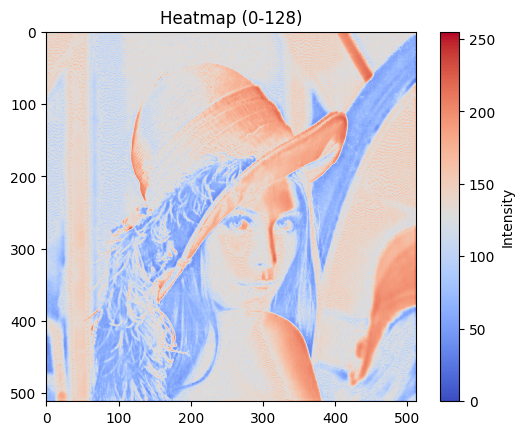

In [147]:
dst_img = Image.fromarray(dithered_img)
plt.imshow(err_img, cmap='coolwarm', vmin=0, vmax=255)
plt.colorbar(label='Intensity')
plt.title('Heatmap (0-128)')
plt.show()
dst_img.show()

# Different between error images

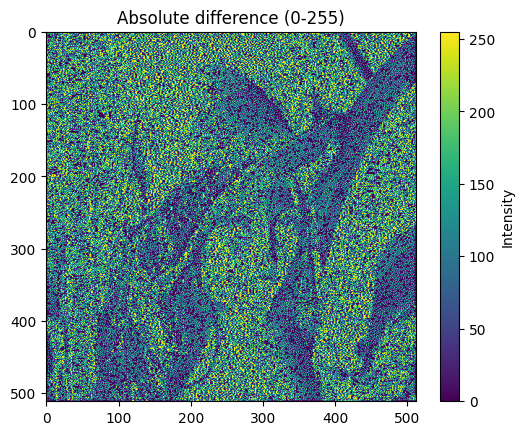

In [32]:
err_img_diff = np.abs(dithered_img_ls - dithered_img_a)
plt.imshow(err_img_diff, cmap='viridis', vmin=0, vmax=255)
plt.colorbar(label='Intensity')
plt.title('Absolute difference (0-255)')
plt.show()

In [33]:
euclidean_distance = np.linalg.norm(dithered_img_ls - dithered_img_a)
print(euclidean_distance)

83014.93570436587
